# Project — Will the client subscribe? A cost-aware bank-marketing classifier

A bank runs a phone campaign selling **term deposits**. Calling everyone is expensive, and
only about **11%** of clients subscribe. Your job is the same shape as the cheese factory from
the lectures: turn a model's **scores** into a **decision** that respects an **asymmetric cost**
(a wasted call is cheap; a missed subscriber is expensive), and report **probabilities you can
trust**.

You will build the whole pipeline end to end:

1. **Setup & first look** — load the data, see the imbalance.
2. **Split & a baseline to beat** — train/val/test; why "predict no one" is useless despite 88% accuracy.
3. **The leakage trap** — one feature (`duration`) inflates the score; measure it, then drop it.
4. **Logistic regression & interpretation** — fit it, read the coefficients as odds ratios.
5. **The right metric & operating point** — PR over ROC on imbalanced data; tune the threshold **by cost**.
6. **Calibration** — are the probabilities trustworthy? (and what `class_weight` does to them.)
7. **Sealed-test evaluation & model card** — score once, write it up.

Dataset: UCI Bank Marketing (`data/bank-full.csv`), 45,211 clients, target `y` = subscribed (yes/no).

## Part 1 — Setup & first look

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 509
ARM_BLUE, ARM_RED, ARM_ORANGE = "#0033A0", "#D90012", "#F2A800"

df = pd.read_csv("data/bank-full.csv", sep=";")
df["y"] = (df["y"] == "yes").astype(int)
print("shape:", df.shape)
df.head()

shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


**The target.** How (im)balanced is it? What accuracy would a model that just predicts the majority class get?

In [2]:
rate = df["y"].mean()
print(f"positive rate (subscribed): {rate:.3f}")
print(df["y"].value_counts())
print(f"\n'predict no one subscribes' would be {1 - rate:.1%} accurate -- and catch 0 subscribers.")

positive rate (subscribed): 0.117
y
0    39922
1     5289
Name: count, dtype: int64

'predict no one subscribes' would be 88.3% accurate -- and catch 0 subscribers.


**Data quirks (look before you model).** Two things to handle:

- `pdays = -1` is a **sentinel** meaning "this client was never contacted in a previous campaign" — not a real "-1 days". Feeding it raw to a scaler is wrong. We add a `was_contacted_before` flag and set those `pdays` to 0.
- Several categorical columns contain an `"unknown"` level (e.g. `contact`, `poutcome`). That is a legitimate category — one-hot encoding will just give it its own column.

In [3]:
print(f"never contacted before (pdays == -1): {(df['pdays'] == -1).mean():.1%}")
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)
df.loc[df["pdays"] == -1, "pdays"] = 0

for c in ["job", "education", "contact", "poutcome"]:
    share = (df[c] == "unknown").mean()
    if share:
        print(f"  '{c}': {share:.1%} unknown")

never contacted before (pdays == -1): 81.7%
  'job': 0.6% unknown
  'education': 4.1% unknown
  'contact': 28.8% unknown
  'poutcome': 81.7% unknown


Define the column groups we will preprocess differently. (`duration` is included **for now** — Part 3 deals with it.)

In [4]:
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous",
            "was_contacted_before"]
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact",
            "month", "poutcome"]
X = df.drop(columns="y")
y = df["y"].values
print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical features")

8 numeric, 9 categorical features


## Part 2 — Split & a baseline to beat

We use **three** splits, not two:

- **train** — fit the model;
- **validation** — pick the threshold and check calibration;
- **test** — touched **once**, at the very end, for the number we report.

Tuning the threshold on the same data you report on would bias the result optimistically.

In [5]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)
print(f"train={len(y_tr)}, val={len(y_val)}, test={len(y_te)}")
print(f"positive rate preserved: {y_tr.mean():.3f} / {y_val.mean():.3f} / {y_te.mean():.3f}")

train=27126, val=9042, test=9043
positive rate preserved: 0.117 / 0.117 / 0.117


**The baseline.** `DummyClassifier` predicts the majority class. High accuracy, zero recall — the lecture's whole point, on real data.

In [6]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
print(f"dummy accuracy: {dummy.score(X_val, y_val):.3f}")
print(f"dummy recall:   {recall_score(y_val, dummy.predict(X_val)):.3f}")
print("High accuracy, catches nobody. Accuracy is the wrong lens here.")

dummy accuracy: 0.883
dummy recall:   0.000
High accuracy, catches nobody. Accuracy is the wrong lens here.


## Part 3 — Preprocess, then the leakage trap

**Preprocessing in a `Pipeline`** so scaling/encoding are fit on *train only* (no leakage):
`StandardScaler` for numerics, `OneHotEncoder(drop="first")` for categoricals.

In [7]:
def make_pipe(numeric, class_weight=None, penalty="l2", C=1.0, solver="lbfgs"):
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="error"), cat_cols),
    ])
    clf = LogisticRegression(max_iter=2000, class_weight=class_weight,
                             penalty=penalty, C=C, solver=solver)
    return Pipeline([("pre", pre), ("clf", clf)])

**The leakage trap.** `duration` is the length of the call in seconds. You only know it
*after* the call has happened — so a model that uses it to decide *whom to call* is cheating.
Let's measure how much it inflates the score, then drop it.

In [8]:
pipe_leaky = make_pipe(num_cols).fit(X_tr, y_tr)          # WITH duration
auc_leaky = roc_auc_score(y_val, pipe_leaky.predict_proba(X_val)[:, 1])

num_honest = [c for c in num_cols if c != "duration"]     # WITHOUT duration
pipe = make_pipe(num_honest).fit(X_tr, y_tr)
s_val = pipe.predict_proba(X_val)[:, 1]
auc_honest = roc_auc_score(y_val, s_val)

print(f"val ROC AUC WITH duration (leaky):    {auc_leaky:.3f}")
print(f"val ROC AUC WITHOUT duration (honest): {auc_honest:.3f}")
print(f"leakage inflated the AUC by {auc_leaky - auc_honest:.3f}")

val ROC AUC WITH duration (leaky):    0.902
val ROC AUC WITHOUT duration (honest): 0.762
leakage inflated the AUC by 0.140


> **Takeaway.** The leaky model looks better, but its score is a fantasy — at decision time
> you don't have `duration`. We keep the **honest** model (`pipe`, no `duration`) for everything below.

## Part 4 — Logistic regression & interpreting it

`pipe` is our fitted logistic regression. Logreg's superpower is interpretability:
`exp(coef)` is an **odds ratio**. Because the numerics are standardized, their odds ratios are
**per one standard deviation** (handy: they're directly comparable). One-hot columns are 0/1,
so their odds ratio is "this category vs the dropped reference" — so print the reference too.

dropped reference category per feature: {'job': 'admin.', 'marital': 'divorced', 'education': 'primary', 'default': 'no', 'housing': 'no', 'loan': 'no', 'contact': 'cellular', 'month': 'apr', 'poutcome': 'failure'}


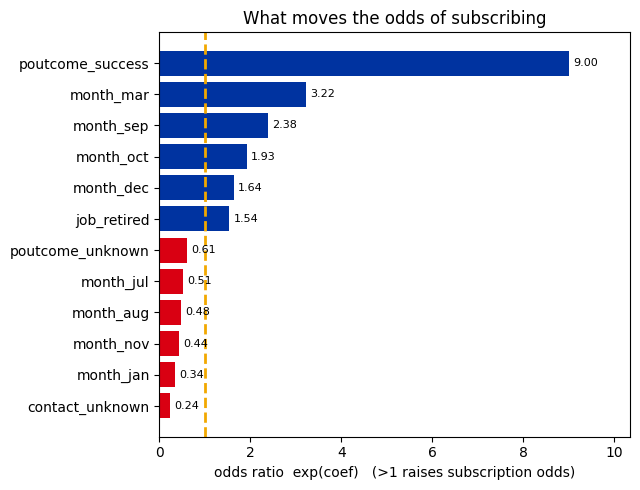

Strongest positive: {'month_sep': 2.38, 'month_mar': 3.22, 'poutcome_success': 9.0}
Strongest negative: {'contact_unknown': 0.24, 'month_jan': 0.34, 'month_nov': 0.44}


In [9]:
ohe = pipe.named_steps["pre"].named_transformers_["cat"]
feat_names = num_honest + list(ohe.get_feature_names_out(cat_cols))
coef = pipe.named_steps["clf"].coef_.ravel()
odds = pd.Series(np.exp(coef), index=feat_names).sort_values()

refs = {c: list(cats)[0] for c, cats in zip(cat_cols, ohe.categories_)}
print("dropped reference category per feature:", refs)

top = pd.concat([odds.head(6), odds.tail(6)])
fig, ax = plt.subplots(figsize=(6.5, 5))
colors = [ARM_RED if v < 1 else ARM_BLUE for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.axvline(1, color=ARM_ORANGE, lw=2, ls="--")
ax.set_yticks(range(len(top)), top.index)
ax.set_xlabel("odds ratio  exp(coef)   (>1 raises subscription odds)")
ax.set_title("What moves the odds of subscribing")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=8)
ax.margins(x=0.15)
plt.tight_layout(); plt.show()

print("Strongest positive:", odds.tail(3).round(2).to_dict())
print("Strongest negative:", odds.head(3).round(2).to_dict())

> **Caveat.** These are **standardized** (per-SD) odds ratios — great for comparing feature
> strength, but *not* "per extra euro / per extra year". For per-unit odds ratios you would fit
> on the raw, unscaled features.

## Part 5 — The right metric, then the operating point

At 11% positives, **accuracy and ROC overstate**. Report **PR AUC (average precision)** alongside
ROC, and read precision/recall at an operating point.

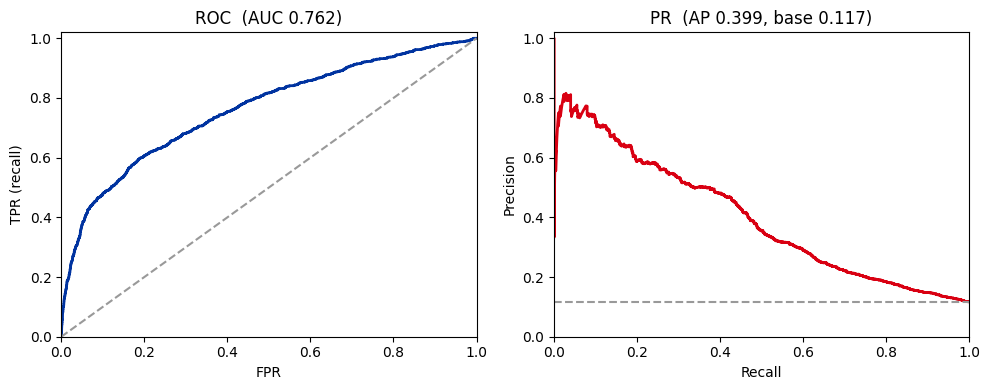

ROC AUC 0.762  vs  PR AUC 0.399  (PR is the honest one here).


In [10]:
roc_auc = roc_auc_score(y_val, s_val)
pr_auc = average_precision_score(y_val, s_val)
base = y_val.mean()
fpr, tpr, _ = roc_curve(y_val, s_val)
prec, rec, _ = precision_recall_curve(y_val, s_val)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
a1.plot(fpr, tpr, color=ARM_BLUE, lw=2); a1.plot([0, 1], [0, 1], "--", color="0.6")
a1.set_xlabel("FPR"); a1.set_ylabel("TPR (recall)"); a1.set_title(f"ROC  (AUC {roc_auc:.3f})")
a2.plot(rec, prec, color=ARM_RED, lw=2); a2.axhline(base, ls="--", color="0.6")
a2.set_xlabel("Recall"); a2.set_ylabel("Precision"); a2.set_title(f"PR  (AP {pr_auc:.3f}, base {base:.3f})")
for a in (a1, a2): a.set_xlim(0, 1); a.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()
print(f"ROC AUC {roc_auc:.3f}  vs  PR AUC {pr_auc:.3f}  (PR is the honest one here).")

**Choose the threshold by cost, not by 0.5.** Suppose a wasted call costs **€5** and a missed
subscriber costs **€100** (lost net value). We count only the **error** costs (a made sale nets
value minus the call); minimise expected error cost on validation.
Because we did **not** reweight the classes, the probabilities are honest, so the empirical
optimum should land near the closed-form `C_FP / (C_FN + C_FP)`.

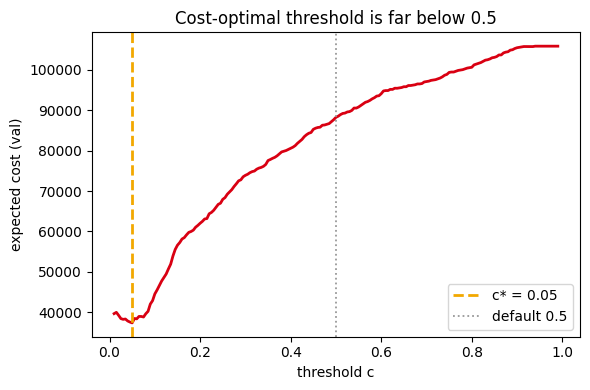

c* = 0.050  (closed-form 0.048); cost at c* = 37,415 vs at 0.5 = 88,215


In [11]:
C_FP, C_FN = 5, 100
ts = np.linspace(0.01, 0.99, 197)

def total_cost(yv, sv, t):
    pred = sv >= t
    fp = np.sum(pred & (yv == 0)); fn = np.sum((~pred) & (yv == 1))
    return C_FP * fp + C_FN * fn

costs = np.array([total_cost(y_val, s_val, t) for t in ts])
c_star = ts[int(np.argmin(costs))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ts, costs, color=ARM_RED, lw=2)
ax.axvline(c_star, color=ARM_ORANGE, lw=2, ls="--", label=f"c* = {c_star:.2f}")
ax.axvline(0.5, color="0.6", lw=1.3, ls=":", label="default 0.5")
ax.set_xlabel("threshold c"); ax.set_ylabel("expected cost (val)")
ax.set_title("Cost-optimal threshold is far below 0.5"); ax.legend()
plt.tight_layout(); plt.show()
print(f"c* = {c_star:.3f}  (closed-form {C_FP/(C_FN+C_FP):.3f}); "
      f"cost at c* = {costs.min():,.0f} vs at 0.5 = {total_cost(y_val, s_val, 0.5):,.0f}")

## Part 6 — Are the probabilities trustworthy? (calibration)

A cost decision (and any "this client has an 80% chance" statement) only means something if the
probabilities are **calibrated**. Logistic regression minimises log-loss (a proper scoring rule),
so it is usually well calibrated — let's check, and then see what `class_weight="balanced"` does to it.

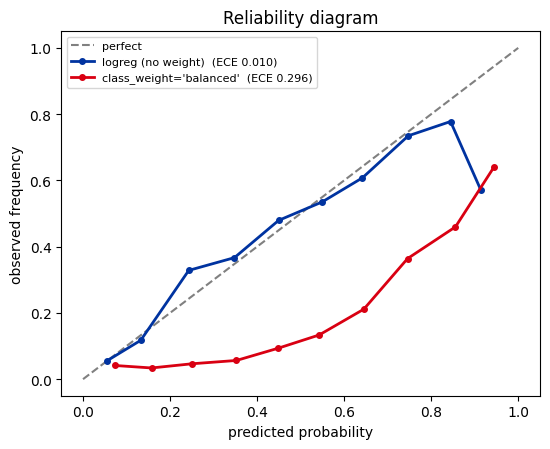

no-weight mean prediction 0.117  vs  true rate 0.117
balanced  mean prediction 0.413  -- inflated, so it would need re-calibration.


In [12]:
def ece(yv, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    return sum((m.sum()/len(p)) * abs(yv[m].mean() - p[m].mean())
               for m in (idx == b for b in range(n_bins)) if m.sum())

# the cautionary comparison: same model, but class_weight="balanced"
pipe_bal = make_pipe(num_honest, class_weight="balanced").fit(X_tr, y_tr)
s_val_bal = pipe_bal.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="perfect")
for name, p, c in [("logreg (no weight)", s_val, ARM_BLUE),
                   ("class_weight='balanced'", s_val_bal, ARM_RED)]:
    frac, mean = calibration_curve(y_val, p, n_bins=10, strategy="uniform")
    ax.plot(mean, frac, "-o", color=c, lw=2, ms=4, label=f"{name}  (ECE {ece(y_val, p):.3f})")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Reliability diagram"); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
print(f"no-weight mean prediction {s_val.mean():.3f}  vs  true rate {y_val.mean():.3f}")
print(f"balanced  mean prediction {s_val_bal.mean():.3f}  -- inflated, so it would need re-calibration.")

> **Takeaway.** The plain logreg is well calibrated, so the cost-optimal threshold above is
> meaningful. `class_weight="balanced"` improves nothing here and **distorts the probabilities**
> (it inflates them far above the 11% base rate) — if you used it you would have to re-calibrate.
> That's why we handled the imbalance with the **threshold**, not by reweighting.

## Part 7 — Sealed-test evaluation & model card

Now, and only now, touch the test set: apply the honest pipeline at `c*` **once**.
(For an actual deployment you would refit on train+val before shipping; we keep the train-only
model so this test estimate stays honest.)

TEST  PR AUC        : 0.415
TEST  recall  @ c*  : 0.910
TEST  precision @ c*: 0.145
TEST  F1       @ c* : 0.250
TEST  cost @ c* = 37,855  vs  @0.5 = 88,070  (saving 57%)


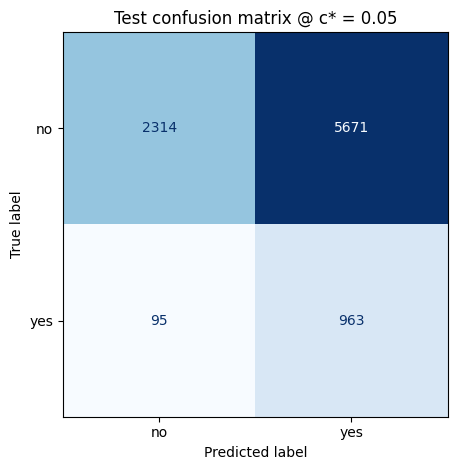

In [13]:
s_te = pipe.predict_proba(X_te)[:, 1]
pred_te = (s_te >= c_star).astype(int)

print(f"TEST  PR AUC        : {average_precision_score(y_te, s_te):.3f}")
print(f"TEST  recall  @ c*  : {recall_score(y_te, pred_te):.3f}")
print(f"TEST  precision @ c*: {precision_score(y_te, pred_te):.3f}")
print(f"TEST  F1       @ c* : {f1_score(y_te, pred_te):.3f}")
cost_star = C_FP*np.sum(pred_te & (y_te==0)) + C_FN*np.sum((pred_te==0) & (y_te==1))
cost_half = (lambda p: C_FP*np.sum(p & (y_te==0)) + C_FN*np.sum((p==0) & (y_te==1)))((s_te>=0.5).astype(int))
print(f"TEST  cost @ c* = {cost_star:,.0f}  vs  @0.5 = {cost_half:,.0f}  "
      f"(saving {100*(1-cost_star/cost_half):.0f}%)")

ConfusionMatrixDisplay(confusion_matrix(y_te, pred_te),
                       display_labels=["no", "yes"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Test confusion matrix @ c* = {c_star:.2f}"); plt.tight_layout(); plt.show()

### Model card

| Field | Value |
|---|---|
| **Task** | Predict term-deposit subscription (binary), to target a phone campaign |
| **Data** | UCI Bank Marketing, 45,211 clients, 11.7% positive |
| **Leakage handled** | Dropped `duration` (known only after the call); `pdays = -1` sentinel → flag + 0 |
| **Model** | Logistic regression (L2), standardized numerics + one-hot categoricals, **no** class reweighting |
| **Headline metric** | PR AUC (average precision) — ROC overstates on 11% positives |
| **Operating point** | Threshold `c*` chosen by expected cost (call €5, missed sale €100) on validation, far below 0.5 |
| **Calibration** | Well calibrated (low ECE); reweighting was rejected because it distorts probabilities |
| **Limitations** | One validation split (not nested CV); costs are illustrative; campaign/contact features are time-specific |

> **One-line takeaway:** at 11% positives the model is only useful once you (1) drop the leaky
> feature, (2) judge it with PR not accuracy, and (3) move the threshold to match the cost of a
> missed customer — exactly the L11→L12→L13 arc.

## Going further (optional)

**A. Lift / gain — "we can only call the top 20%."** How many subscribers do we catch?
(Use the **validation** set — the test set is already spent.)

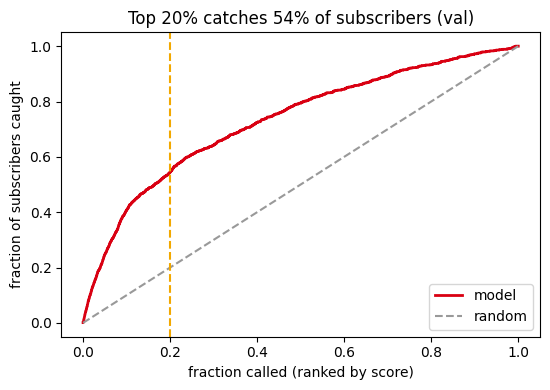

lift at top 20% = 2.7x random


In [14]:
order = np.argsort(-s_val)
gain = np.cumsum(y_val[order]) / y_val.sum()
frac = np.arange(1, len(y_val) + 1) / len(y_val)
k = int(0.20 * len(y_val))
fig, ax = plt.subplots(figsize=(5.6, 4))
ax.plot(frac, gain, color=ARM_RED, lw=2, label="model")
ax.plot([0, 1], [0, 1], "--", color="0.6", label="random")
ax.axvline(0.20, color=ARM_ORANGE, ls="--")
ax.set_xlabel("fraction called (ranked by score)"); ax.set_ylabel("fraction of subscribers caught")
ax.set_title(f"Top 20% catches {gain[k]:.0%} of subscribers (val)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"lift at top 20% = {gain[k]/0.20:.1f}x random")

**B. Sparsity with L1.** Does an L1 penalty zero out features without hurting PR AUC?

In [15]:
pipe_l1 = make_pipe(num_honest, penalty="l1", C=0.1, solver="liblinear").fit(X_tr, y_tr)
n_zero = int(np.sum(pipe_l1.named_steps["clf"].coef_.ravel() == 0))
n_tot = pipe_l1.named_steps["clf"].coef_.size
ap_l1 = average_precision_score(y_val, pipe_l1.predict_proba(X_val)[:, 1])
print(f"L1 (C=0.1): {n_zero}/{n_tot} coefficients = 0;  val PR AUC {ap_l1:.3f} "
      f"(vs {average_precision_score(y_val, s_val):.3f} for the full model)")

L1 (C=0.1): 10/42 coefficients = 0;  val PR AUC 0.400 (vs 0.399 for the full model)
